> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.


Run 0: κ_init = 3.9e-08
Phase 1: Learning temperature field (no physics)...
  Phase1 iter 10000, bc=0.000047, data=0.000014
  Phase1 iter 20000, bc=0.000008, data=0.000001
  Phase1 iter 30000, bc=0.000004, data=0.000003
  Phase1 iter 40000, bc=0.000002, data=0.000001
  Phase1 iter 50000, bc=0.000003, data=0.000000
Phase 3: Fine-tuning κ (networks frozen)...
  Phase3 iter 10000, κ=9.4622e-08, phys=320.342010
  Phase3 iter 20000, κ=2.2644e-07, phys=319.995056
  Phase3 iter 30000, κ=5.5095e-07, phys=319.879761
  Phase3 iter 40000, κ=1.3503e-06, phys=319.837616
  Phase3 iter 50000, κ=3.3375e-06, phys=319.821228

Run 1: κ_init = 6.3e-08
Phase 1: Learning temperature field (no physics)...
  Phase1 iter 10000, bc=0.000047, data=0.000014
  Phase1 iter 20000, bc=0.000008, data=0.000001
  Phase1 iter 30000, bc=0.000004, data=0.000003
  Phase1 iter 40000, bc=0.000002, data=0.000001
  Phase1 iter 50000, bc=0.000003, data=0.000000
Phase 3: Fine-tuning κ (networks frozen)...
  Phase3 iter 10000, κ=

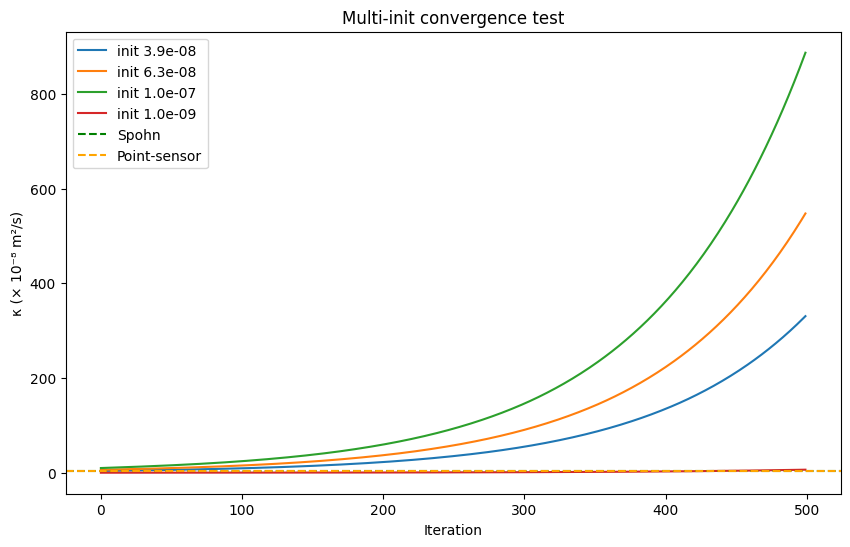

In [2]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.5           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


import pickle



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass


# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)


#-------- 1. Boundary Condition points used for Perturbation network --------
n_surface = len(ltst_surf)  # Should be 552


# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)


# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

## Boudnaries at top and bottom of mole. mole is isothermal, so we will enforce the same temperature at the top and bottom of the mole. 

# Mole top boundary (z = z_0))
t_bc_mole_top = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_top = jnp.ones((len(ltst_mole), 1)) * z_0


# Mole bottom boundary (z = z_1))
t_bc_mole_bottom = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_bottom = jnp.ones((len(ltst_mole), 1)) * z_1


u_bc_mole = jnp.array(temp_mole).reshape(-1, 1)

# #Join all bcs except the mole surface

# t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
# x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
# u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])  

# 2. Physics collocation points (50 * 50 = 2500 points). Soil is only on the top and bottom
t_physics_top = random.uniform(key1, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_top = random.uniform(key2, (2500, 1), minval=0, maxval=z_0)

t_physics_bottom = random.uniform(key3, (5000, 1), minval=0, maxval=sol_seconds)
x_physics_bottom = random.uniform(key4, (5000, 1), minval=z_1, maxval=z_max)

# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Top region: z ∈ [0, z_0] → [0, 1]
def normalize_z_top(z): return z / z_0

# Bottom region: z ∈ [z_1, z_max] → [0, 1]  
def normalize_z_bottom(z): return (z - z_1) / (z_max - z_1)


# Normalize all data

t_bc_surface = normalize_t(t_bc_surface)
x_bc_surface = normalize_z_top(x_bc_surface)
u_bc_surface = normalize_u(u_bc_surface)

t_bc_bottom = normalize_t(t_bc_bottom)
x_bc_bottom = normalize_z_bottom(x_bc_bottom)
u_bc_bottom = normalize_u(u_bc_bottom)

u_bc_mole = normalize_u(u_bc_mole)

t_physics_top = normalize_t(t_physics_top)
x_physics_top = normalize_z_top(x_physics_top)

t_physics_bottom = normalize_t(t_physics_bottom)
x_physics_bottom = normalize_z_bottom(x_physics_bottom)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

def normalize_kappa_top(kappa):
    return kappa * (t_max - t_min) / ((z_0)**2)

def normalize_kappa_bottom(kappa):
    return kappa * (t_max - t_min) / ((z_max - z_1)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        region: String indicating the region ('top' or 'bottom')
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)



    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)


    return du_dt / kappa - d2u_dx2

physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))


all_kappa_histories = {}


for run_idx,kappa_init in enumerate([3.93e-8, 6.3e-8, 1e-7, 1e-9]):

    # Initialize network
    key = random.PRNGKey(123)
    key, key1 = random.split(key)
    layer_sizes = [2, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
    # Two networks, one per soil region
    params_top = init_network_params(layer_sizes, key)
    params_bot = init_network_params(layer_sizes, key1)

    # import pickle
    # # Load pre-trained weights for the forward problem (trained with kappa = 3.93e-8)
    # with open('forward_checkpoint/forward_warmstart_3.93e-8.pkl', 'rb') as f:
    #     loaded_params = pickle.load(f)

    params = { 'top': params_top, 'bottom': params_bot, 'log_kappa': jnp.log(kappa_init) }

    # Initialize optimizer
    # Different schedules for network weights vs kappa
    net_schedule = optax.piecewise_constant_schedule(
        init_value=1e-3, boundaries_and_scales={80000: 0.1, 160000: 0.01})
    kappa_schedule = optax.piecewise_constant_schedule(
        init_value=1e-4, boundaries_and_scales={270000: 0.1})  # slower, more conservative

    

    # ── PHASE 1: Data only — lock in the temperature field ──
    optimizer_phase1 = optax.multi_transform(
        transforms={
            'network': optax.adam(1e-3),
            'kappa': optax.adam(0.0),  # κ frozen
        },
        param_labels={'top': 'network', 'bottom': 'network', 'log_kappa': 'kappa'}
    )
    opt_state = optimizer_phase1.init(params)

    @jit
    def update_phase1(params, opt_state,
                      t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom,
                      u_bc_surface, u_bc_bottom,
                      t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom,
                      u_bc_mole):
        def loss_fn(params):
            tx_s = jnp.concatenate([t_bc_surface, x_bc_surface], axis=1)
            tx_b = jnp.concatenate([t_bc_bottom, x_bc_bottom], axis=1)
            
            bc_loss = (jnp.mean((network(params['top'], tx_s) - u_bc_surface)**2) +
                       jnp.mean((network(params['bottom'], tx_b) - u_bc_bottom)**2))
            
            mole_top = network(params['top'], jnp.concatenate(
                [normalize_t(t_bc_mole_top), normalize_z_top(x_bc_mole_top)], axis=1))
            mole_bot = network(params['bottom'], jnp.concatenate(
                [normalize_t(t_bc_mole_bottom), normalize_z_bottom(x_bc_mole_bottom)], axis=1))
            
            data_loss = (jnp.mean((mole_top - u_bc_mole)**2) +
                         jnp.mean((mole_bot - u_bc_mole)**2))
            
            return 20.0 * bc_loss + 50.0 * data_loss, (bc_loss, data_loss)
        
        (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, new_opt = optimizer_phase1.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss, aux

    print(f"\n{'='*50}")
    print(f"Run {run_idx}: κ_init = {kappa_init:.1e}")
    print(f"Phase 1: Learning temperature field (no physics)...")
    
    for i in range(50000):
        params, opt_state, loss, aux = update_phase1(
            params, opt_state,
            t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom,
            u_bc_surface, u_bc_bottom,
            t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom,
            u_bc_mole)
        if (i + 1) % 10000 == 0:
            print(f"  Phase1 iter {i+1}, bc={aux[0]:.6f}, data={aux[1]:.6f}")

    kappa_history = []

    # # ── PHASE 2: Add physics, learn κ with slow networks ──
    # print(f"Phase 2: Learning κ (physics on, networks slow)...")
    
    # optimizer_phase2 = optax.multi_transform(
    #     transforms={
    #         'network': optax.adam(1e-5),   # networks barely move
    #         'kappa': optax.adam(1e-4),      # κ moves freely
    #     },
    #     param_labels={'top': 'network', 'bottom': 'network', 'log_kappa': 'kappa'}
    # )
    # opt_state = optimizer_phase2.init(params)

    # @jit
    # def update_phase2(params, opt_state,
    #                   t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom,
    #                   u_bc_surface, u_bc_bottom,
    #                   t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom,
    #                   u_bc_mole,
    #                   t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom):
    #     def loss_fn(params):
    #         # Same BC + data losses
    #         tx_s = jnp.concatenate([t_bc_surface, x_bc_surface], axis=1)
    #         tx_b = jnp.concatenate([t_bc_bottom, x_bc_bottom], axis=1)
    #         bc_loss = (jnp.mean((network(params['top'], tx_s) - u_bc_surface)**2) +
    #                    jnp.mean((network(params['bottom'], tx_b) - u_bc_bottom)**2))
            
    #         mole_top = network(params['top'], jnp.concatenate(
    #             [normalize_t(t_bc_mole_top), normalize_z_top(x_bc_mole_top)], axis=1))
    #         mole_bot = network(params['bottom'], jnp.concatenate(
    #             [normalize_t(t_bc_mole_bottom), normalize_z_bottom(x_bc_mole_bottom)], axis=1))
    #         data_loss = (jnp.mean((mole_top - u_bc_mole)**2) +
    #                      jnp.mean((mole_bot - u_bc_mole)**2))
            
    #         # Physics loss with learnable κ
    #         k = jnp.exp(params['log_kappa'])
    #         kt = normalize_kappa_top(k)
    #         kb = normalize_kappa_bottom(k)
    #         res_top = physics_residual_batch(params['top'],
    #             t_physics_top.ravel(), x_physics_top.ravel(), kt)
    #         res_bot = physics_residual_batch(params['bottom'],
    #             t_physics_bottom.ravel(), x_physics_bottom.ravel(), kb)
    #         physics_loss = jnp.mean(res_top**2) + jnp.mean(res_bot**2)
            
    #         return 20.0 * bc_loss + 50.0 * data_loss + 1.0 * physics_loss, (bc_loss, physics_loss, data_loss)
        
    #     (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    #     updates, new_opt = optimizer_phase2.update(grads, opt_state, params)
    #     return optax.apply_updates(params, updates), new_opt, loss, aux

    
    # for i in range(150000):
    #     params, opt_state, loss, aux = update_phase2(
    #         params, opt_state,
    #         t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom,
    #         u_bc_surface, u_bc_bottom,
    #         t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom,
    #         u_bc_mole,
    #         t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom)
        
    #     kappa_history.append(float(jnp.exp(params['log_kappa'])))
        
    #     if (i + 1) % 10000 == 0:
    #         print(f"  Phase2 iter {i+1}, κ={jnp.exp(params['log_kappa']):.4e}, "
    #               f"phys={aux[1]:.6f}")

    # all_kappa_histories[kappa_init] = kappa_history

    # ── PHASE 3: Networks frozen, only κ learns ──
    print(f"Phase 3: Fine-tuning κ (networks frozen)...")
    
    optimizer_phase3 = optax.multi_transform(
        transforms={
            'network': optax.adam(0.0),    # completely frozen
            'kappa': optax.adam(1e-4),
        },
        param_labels={'top': 'network', 'bottom': 'network', 'log_kappa': 'kappa'}
    )
    opt_state = optimizer_phase3.init(params)

    # Reuse update_phase2 — same loss function, different optimizer
    @jit
    def update_phase3(params, opt_state,
                      t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom,
                      u_bc_surface, u_bc_bottom,
                      t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom,
                      u_bc_mole,
                      t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom):
        def loss_fn(params):
            tx_s = jnp.concatenate([t_bc_surface, x_bc_surface], axis=1)
            tx_b = jnp.concatenate([t_bc_bottom, x_bc_bottom], axis=1)
            bc_loss = (jnp.mean((network(params['top'], tx_s) - u_bc_surface)**2) +
                       jnp.mean((network(params['bottom'], tx_b) - u_bc_bottom)**2))
            
            mole_top = network(params['top'], jnp.concatenate(
                [normalize_t(t_bc_mole_top), normalize_z_top(x_bc_mole_top)], axis=1))
            mole_bot = network(params['bottom'], jnp.concatenate(
                [normalize_t(t_bc_mole_bottom), normalize_z_bottom(x_bc_mole_bottom)], axis=1))
            data_loss = (jnp.mean((mole_top - u_bc_mole)**2) +
                         jnp.mean((mole_bot - u_bc_mole)**2))
            
            k = jnp.exp(params['log_kappa'])
            res_top = physics_residual_batch(params['top'],
                t_physics_top.ravel(), x_physics_top.ravel(), normalize_kappa_top(k))
            res_bot = physics_residual_batch(params['bottom'],
                t_physics_bottom.ravel(), x_physics_bottom.ravel(), normalize_kappa_bottom(k))
            physics_loss = jnp.mean(res_top**2) + jnp.mean(res_bot**2)
            
            # Only physics matters now — BC/data are frozen anyway
            return physics_loss, (bc_loss, physics_loss, data_loss)
        
        (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, new_opt = optimizer_phase3.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss, aux

    for i in range(50000):
        params, opt_state, loss, aux = update_phase3(
            params, opt_state,
            t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom,
            u_bc_surface, u_bc_bottom,
            t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom,
            u_bc_mole,
            t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom)
        
        kappa_history.append(float(jnp.exp(params['log_kappa'])))
        
        if (i + 1) % 10000 == 0:
            print(f"  Phase3 iter {i+1}, κ={jnp.exp(params['log_kappa']):.4e}, "
                  f"phys={aux[1]:.6f}")

    all_kappa_histories[kappa_init] = kappa_history
    

# After all runs — overlay plot
fig, ax = plt.subplots(figsize=(10, 6))
for kappa_init, hist in all_kappa_histories.items():
    ax.plot(jnp.array(hist)[::100] * 1e8, label=f'init {kappa_init:.1e}')
ax.axhline(3.93, color='green', ls='--', label='Spohn')
ax.axhline(4.19, color='orange', ls='--', label='Point-sensor')
ax.set_xlabel('Iteration')
ax.set_ylabel('κ (× 10⁻⁸ m²/s)')
ax.legend()
ax.set_title('Multi-init convergence test')
plt.savefig('kappa_multi_init_overlay_phase_1&3.png', dpi=150)
plt.show()





In [13]:
# Snapshot where we are
current_kappa = float(jnp.exp(params['log_kappa']))
print(f"Restarting from κ = {current_kappa:.4e}")

# Fresh optimizer — no schedule decay, just a steady moderate LR
optimizer_fine = optax.multi_transform(
    transforms={
        'network': optax.adam(1e-5),   # networks barely need to move
        'kappa': optax.adam(1e-4),     # kappa gets a real LR again
    },
    param_labels={'top': 'network', 'bottom': 'network', 'log_kappa': 'kappa'}
)
opt_state_fine = optimizer_fine.init(params)

# Run 50k more with fresh momentum
kappa_history_fine = []
for i in range(50000):
    params, opt_state, loss, individual_loss = update_step(
                params, opt_state,
                t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom, u_bc_surface, u_bc_bottom,
                t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
                t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom)
    
    kappa_history_fine.append(float(jnp.exp(params['log_kappa'])))
    
    if (i + 1) % 5000 == 0:
        print(f"Fine iter {i+1}/50000, κ = {jnp.exp(params['log_kappa']):.4e}, "
              f"loss = {loss:.6f}, phys = {individual_loss[1]:.6f}")

Restarting from κ = 4.2317e-08
Fine iter 5000/50000, κ = 4.2307e-08, loss = 0.000039, phys = 0.000001
Fine iter 10000/50000, κ = 4.2296e-08, loss = 0.000039, phys = 0.000001
Fine iter 15000/50000, κ = 4.2290e-08, loss = 0.000039, phys = 0.000001
Fine iter 20000/50000, κ = 4.2291e-08, loss = 0.000039, phys = 0.000001
Fine iter 25000/50000, κ = 4.2296e-08, loss = 0.000039, phys = 0.000001
Fine iter 30000/50000, κ = 4.2293e-08, loss = 0.000040, phys = 0.000001
Fine iter 35000/50000, κ = 4.2293e-08, loss = 0.000040, phys = 0.000001
Fine iter 40000/50000, κ = 4.2293e-08, loss = 0.000039, phys = 0.000001
Fine iter 45000/50000, κ = 4.2295e-08, loss = 0.000039, phys = 0.000001
Fine iter 50000/50000, κ = 4.2289e-08, loss = 0.000039, phys = 0.000001


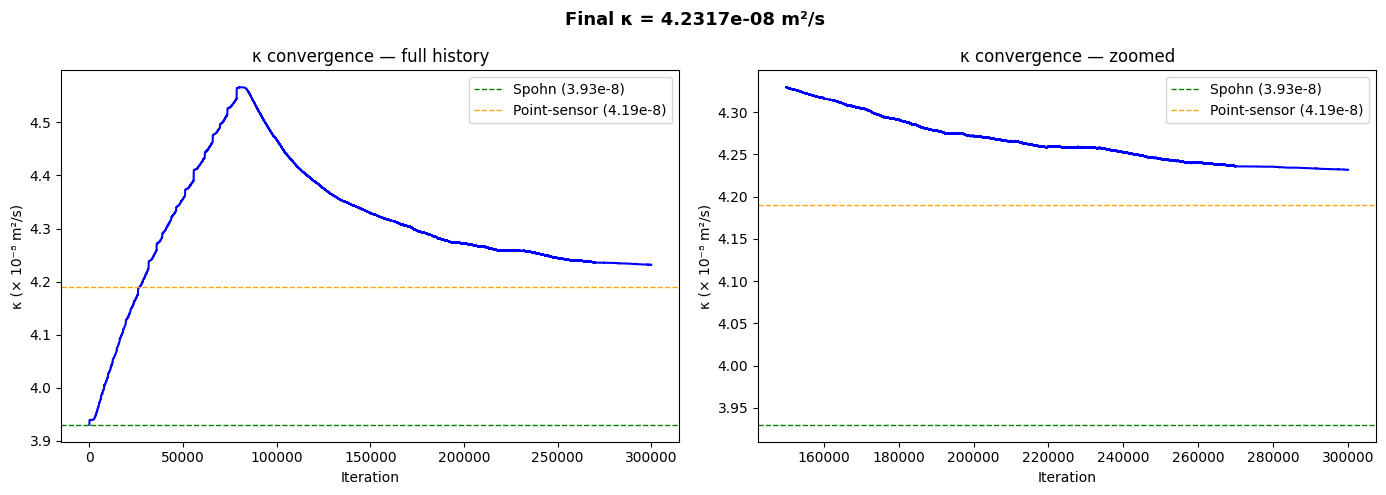

Final κ:          4.2317e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +7.7%)
Point-sensor:     4.19e-8 m²/s  (diff: +1.0%)


In [11]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")
print(f"Point-sensor:     4.19e-8 m²/s  (diff: {(final_kappa - 4.19e-8)/4.19e-8 * 100:+.1f}%)")

## Plots

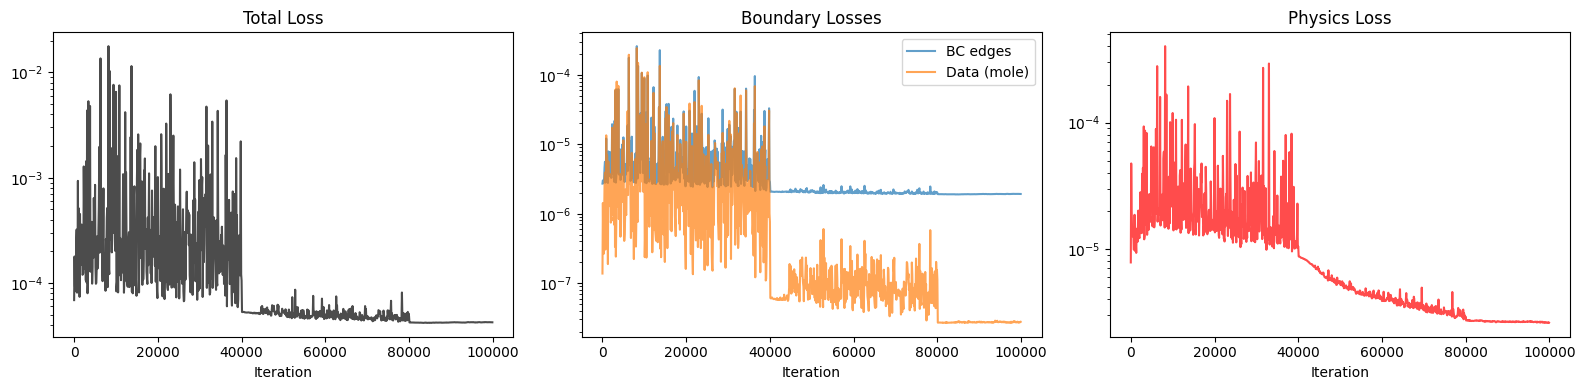

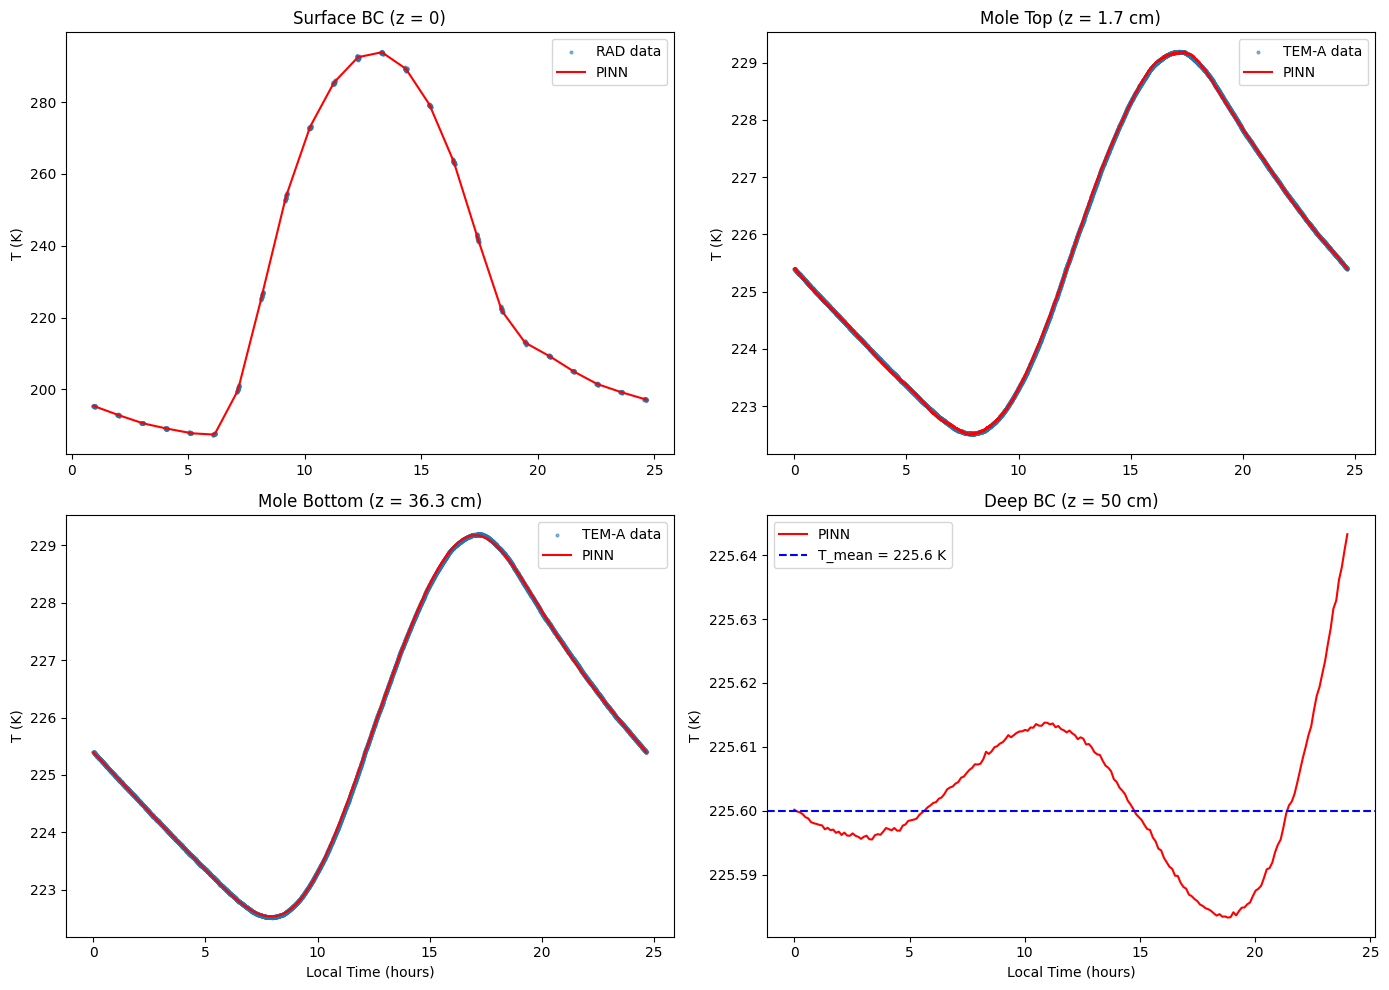

/tmp/ipykernel_572824/4232204144.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


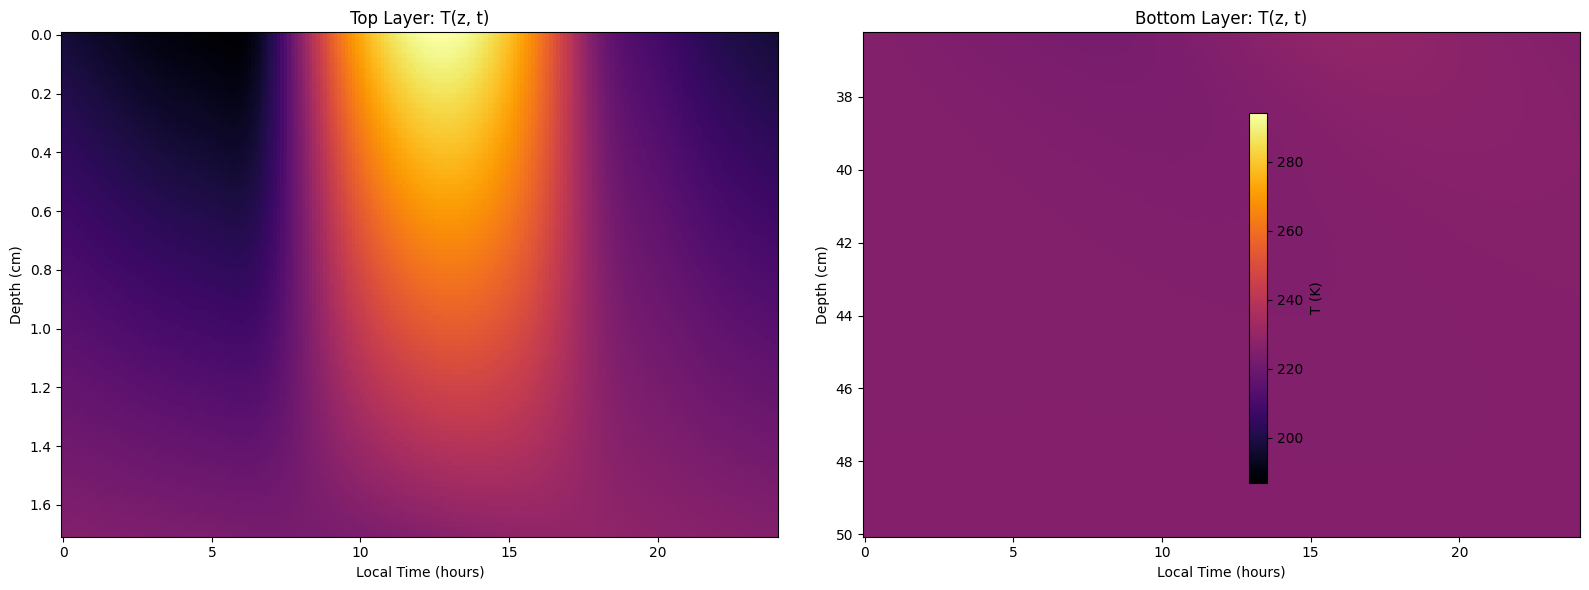

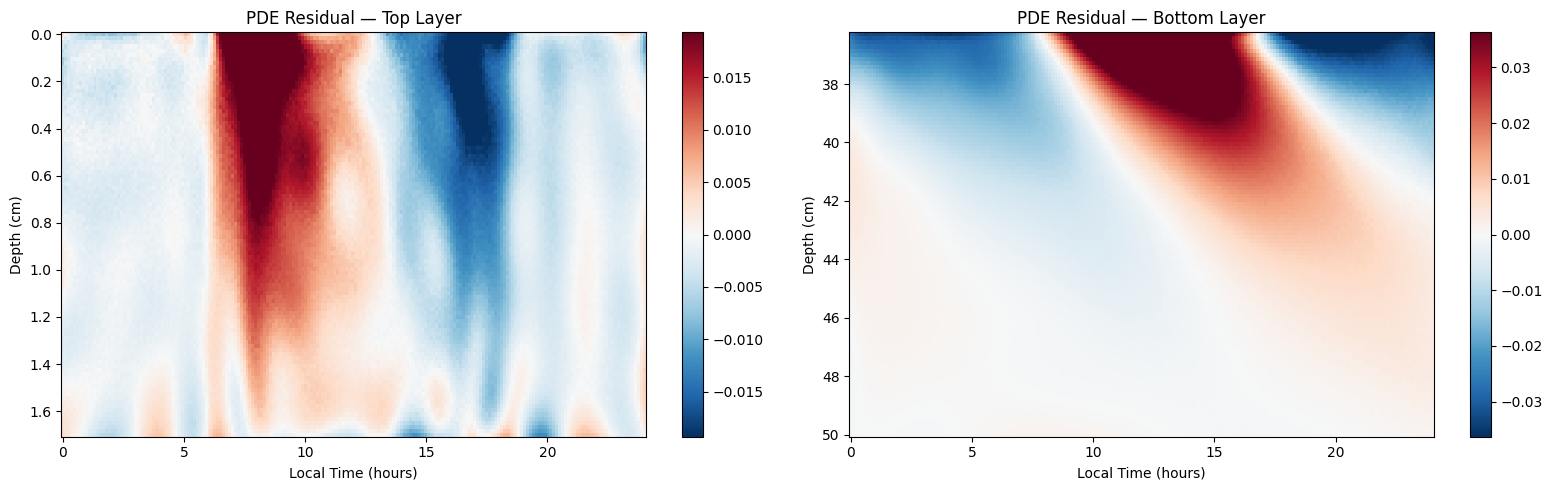

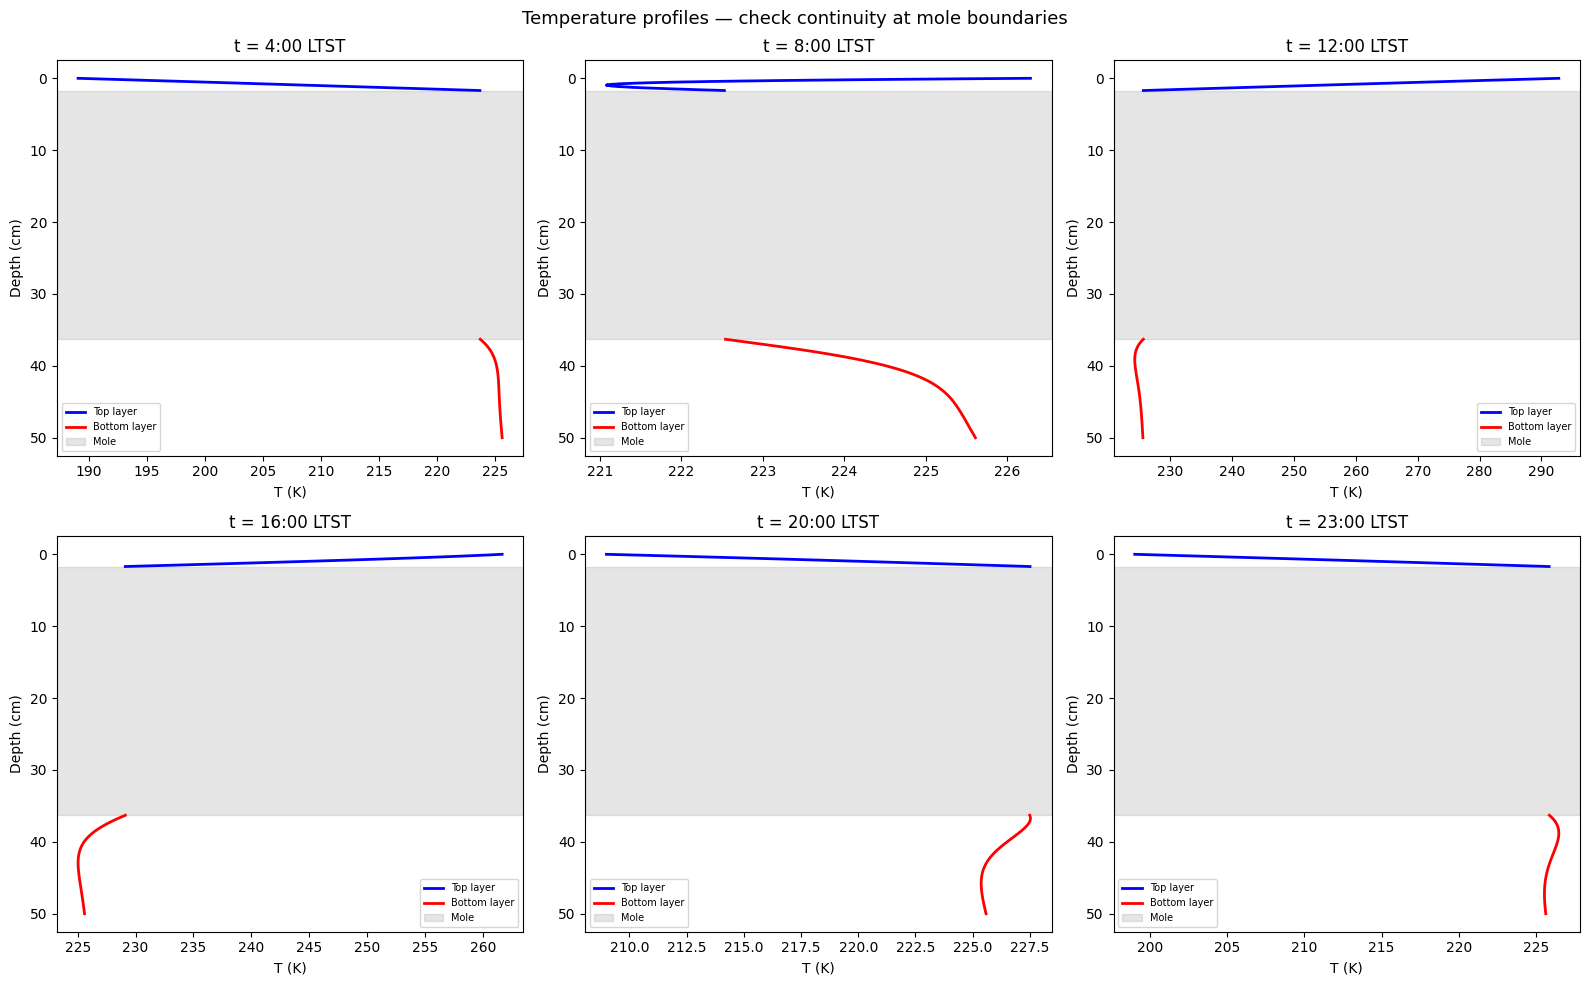

In [2]:
# ── FIGURE 1: Loss curves (downsampled for speed) ──
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# Downsample: plot every 100th point
step = 100
iters = jnp.arange(1, len(losses) + 1)[::step]
l_total = jnp.array(losses)[::step]
l_bc = jnp.array(losses_bc_edges)[::step]
l_data = jnp.array(losses_data)[::step]
l_phys = jnp.array(losses_phys)[::step]

ax[0].semilogy(iters, l_total, 'k-', alpha=0.7)
ax[0].set_title('Total Loss')
ax[0].set_xlabel('Iteration')

ax[1].semilogy(iters, l_bc, label='BC edges', alpha=0.7)
ax[1].semilogy(iters, l_data, label='Data (mole)', alpha=0.7)
ax[1].set_title('Boundary Losses')
ax[1].set_xlabel('Iteration')
ax[1].legend()

ax[2].semilogy(iters, l_phys, 'r-', alpha=0.7)
ax[2].set_title('Physics Loss')
ax[2].set_xlabel('Iteration')

plt.tight_layout()
plt.savefig('2-layers-plots/loss_curves.png', dpi=150)
plt.show()


# ── FIGURE 2: BC fits (all 4 boundaries) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helper: evaluate a network at given (t_seconds, z_physical) using correct normalisation
def predict_top(params, t_sec, z_phys):
    t_norm = normalize_t(jnp.array(t_sec).reshape(-1, 1))
    z_norm = normalize_z_top(jnp.array(z_phys).reshape(-1, 1))
    tx = jnp.concatenate([t_norm, z_norm], axis=1)
    return unormalize_u(network(params['top'], tx)[:, 0])

def predict_bot(params, t_sec, z_phys):
    t_norm = normalize_t(jnp.array(t_sec).reshape(-1, 1))
    z_norm = normalize_z_bottom(jnp.array(z_phys).reshape(-1, 1))
    tx = jnp.concatenate([t_norm, z_norm], axis=1)
    return unormalize_u(network(params['bottom'], tx)[:, 0])

# (a) Surface BC (z=0) — top network
t_surf_hrs = jnp.array(ltst_surf) / 3600
u_surf_pred = predict_top(params, ltst_surf, [0.0] * len(ltst_surf))

axes[0, 0].scatter(t_surf_hrs, temp_surf, s=4, alpha=0.5, label='RAD data')
axes[0, 0].plot(t_surf_hrs, u_surf_pred, 'r-', lw=1.5, label='PINN')
axes[0, 0].set_title('Surface BC (z = 0)')
axes[0, 0].set_ylabel('T (K)')
axes[0, 0].legend()

# (b) Mole top (z=z₀) — top network
t_mole_hrs = jnp.array(ltst_mole) / 3600
u_mole_top_pred = predict_top(params, ltst_mole, [z_0] * len(ltst_mole))

axes[0, 1].scatter(t_mole_hrs, temp_mole, s=4, alpha=0.5, label='TEM-A data')
axes[0, 1].plot(t_mole_hrs, u_mole_top_pred, 'r-', lw=1.5, label='PINN')
axes[0, 1].set_title(f'Mole Top (z = {z_0*100:.1f} cm)')
axes[0, 1].set_ylabel('T (K)')
axes[0, 1].legend()

# (c) Mole bottom (z=z₁) — bottom network
u_mole_bot_pred = predict_bot(params, ltst_mole, [z_1] * len(ltst_mole))

axes[1, 0].scatter(t_mole_hrs, temp_mole, s=4, alpha=0.5, label='TEM-A data')
axes[1, 0].plot(t_mole_hrs, u_mole_bot_pred, 'r-', lw=1.5, label='PINN')
axes[1, 0].set_title(f'Mole Bottom (z = {z_1*100:.1f} cm)')
axes[1, 0].set_ylabel('T (K)')
axes[1, 0].set_xlabel('Local Time (hours)')
axes[1, 0].legend()

# (d) Deep boundary (z=z_max) — bottom network
t_deep_hrs = jnp.linspace(0, 24, 200)
t_deep_sec = t_deep_hrs * sol_seconds / 24
u_deep_pred = predict_bot(params, t_deep_sec, [z_max] * len(t_deep_sec))

axes[1, 1].plot(t_deep_hrs, u_deep_pred, 'r-', lw=1.5, label='PINN')
axes[1, 1].axhline(avg_bottom_temp, color='b', ls='--', label=f'T_mean = {avg_bottom_temp} K')
axes[1, 1].set_title(f'Deep BC (z = {z_max*100:.0f} cm)')
axes[1, 1].set_xlabel('Local Time (hours)')
axes[1, 1].set_ylabel('T (K)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('2-layers-plots/diagnostic_bc_fit_approach2.png', dpi=150)
plt.show()


# ── FIGURE 3: Temperature fields — both regions ──
n_t, n_z = 200, 100

t_grid = jnp.linspace(0, 1, n_t)  # normalised time

# Top region field
z_top_norm = jnp.linspace(0, 1, n_z)
T_top, Z_top = jnp.meshgrid(t_grid, z_top_norm, indexing='ij')
tx_top = jnp.stack([T_top.ravel(), Z_top.ravel()], axis=1)
u_top = unormalize_u(network(params['top'], tx_top)[:, 0]).reshape(n_t, n_z)

# Bottom region field
z_bot_norm = jnp.linspace(0, 1, n_z)
T_bot, Z_bot = jnp.meshgrid(t_grid, z_bot_norm, indexing='ij')
tx_bot = jnp.stack([T_bot.ravel(), Z_bot.ravel()], axis=1)
u_bot = unormalize_u(network(params['bottom'], tx_bot)[:, 0]).reshape(n_t, n_z)

# Physical axes
t_hrs = t_grid * 24
z_top_cm = z_top_norm * z_0 * 100           # [0, 1.7] cm
z_bot_cm = (z_bot_norm * (z_max - z_1) + z_1) * 100  # [36.3, 50] cm

# Shared colour range
vmin = min(u_top.min(), u_bot.min())
vmax = max(u_top.max(), u_bot.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].pcolormesh(t_hrs, z_top_cm, u_top.T, shading='auto', cmap='inferno', vmin=vmin, vmax=vmax)
axes[0].set_title('Top Layer: T(z, t)')
axes[0].set_xlabel('Local Time (hours)')
axes[0].set_ylabel('Depth (cm)')
axes[0].invert_yaxis()

im1 = axes[1].pcolormesh(t_hrs, z_bot_cm, u_bot.T, shading='auto', cmap='inferno', vmin=vmin, vmax=vmax)
axes[1].set_title('Bottom Layer: T(z, t)')
axes[1].set_xlabel('Local Time (hours)')
axes[1].set_ylabel('Depth (cm)')
axes[1].invert_yaxis()

plt.colorbar(im1, ax=axes, label='T (K)', shrink=0.8)
plt.tight_layout()
plt.savefig('2-layers-plots/diagnostic_T_field_approach2.png', dpi=150)
plt.show()


# ── FIGURE 4: PDE residuals — both regions ──
res_top = physics_residual_batch(
    params['top'], T_top.ravel(), Z_top.ravel(), normalize_kappa_top(kappa)
).reshape(n_t, n_z)

res_bot = physics_residual_batch(
    params['bottom'], T_bot.ravel(), Z_bot.ravel(), normalize_kappa_bottom(kappa)
).reshape(n_t, n_z)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vlim_top = jnp.percentile(jnp.abs(res_top), 95)
vlim_bot = jnp.percentile(jnp.abs(res_bot), 95)

im0 = axes[0].pcolormesh(t_hrs, z_top_cm, res_top.T, shading='auto',
                          cmap='RdBu_r', vmin=-vlim_top, vmax=vlim_top)
axes[0].set_title('PDE Residual — Top Layer')
axes[0].set_xlabel('Local Time (hours)')
axes[0].set_ylabel('Depth (cm)')
axes[0].invert_yaxis()
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(t_hrs, z_bot_cm, res_bot.T, shading='auto',
                          cmap='RdBu_r', vmin=-vlim_bot, vmax=vlim_bot)
axes[1].set_title('PDE Residual — Bottom Layer')
axes[1].set_xlabel('Local Time (hours)')
axes[1].set_ylabel('Depth (cm)')
axes[1].invert_yaxis()
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig('2-layers-plots/diagnostic_residual_approach2.png', dpi=150)
plt.show()


# ── FIGURE 5: Time slices — the real physics check ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
slice_hours = [4, 8, 12, 16, 20, 23]

for ax, hr in zip(axes.ravel(), slice_hours):
    idx = min(int(hr / 24 * n_t), n_t - 1)

    # Top layer profile
    ax.plot(u_top[idx, :], z_top_cm, 'b-', lw=2, label='Top layer')

    # Bottom layer profile
    ax.plot(u_bot[idx, :], z_bot_cm, 'r-', lw=2, label='Bottom layer')

    # Grey band for mole region
    ax.axhspan(z_0 * 100, z_1 * 100, color='grey', alpha=0.2, label='Mole')

    ax.set_xlabel('T (K)')
    ax.set_ylabel('Depth (cm)')
    ax.set_title(f't = {hr}:00 LTST')
    ax.invert_yaxis()
    ax.legend(fontsize=7)

plt.suptitle('Temperature profiles — check continuity at mole boundaries', fontsize=13)
plt.tight_layout()
plt.savefig('2-layers-plots/diagnostic_slices_approach2.png', dpi=150)
plt.show()